# Laboratorio 2 — Deep Learning (Series de Tiempo)
## Ejercicio 1: Modelos LSTM — Avance
**Universidad del Valle de Guatemala · Facultad de Ingeniería · Departamento de Ciencias de la Computación**
**CC3084 — Data Science · Semestre II 2026**

**Grupo:** Dulce Ambrosio · Daniel Chet · Javier Linares
**Carné(s):** 231143 · 231177 · 231135

*(Mismo grupo del Laboratorio 1 — actualizar nombres/carnés si es necesario)*

Este cuaderno cubre el **Ejercicio 1** del Laboratorio 2 (avance con fecha de entrega 30/07/2026 17:20):
construir al menos **2 modelos LSTM con configuraciones distintas** para **dos series** del
Laboratorio 1, usando los **mismos conjuntos de entrenamiento y prueba** (split 70/30 temporal),
tunear sus hiperparámetros, seleccionar el mejor modelo por serie, predecir sobre el conjunto de
prueba, y comparar contra los mejores modelos clásicos obtenidos en el Laboratorio 1
(ARIMA/SARIMA, Prophet, Holt-Winters, SES, seasonal naive).

El **Ejercicio 2 (catch22)** y el informe de comparación de algoritmos completo se entregarán en la
**entrega final (2 de agosto de 2026)**.

## 0. Selección de las series

Elegimos **Total mensual** y **Vía Aérea** de las ocho series construidas en el Laboratorio 1, por
tres razones:

1. **Contraste de comportamiento.** En el Laboratorio 1, ambas series representaron los dos
   "casos difíciles" más distintos para los modelos clásicos: en *Total mensual* el SARIMA con
   mejor AIC no logró superar a Prophet porque el corte 70/30 deja toda la caída de la pandemia
   en entrenamiento y la recuperación en prueba; en *Vía Aérea*, el SARIMA (manual y grid-AIC)
   **explotó numéricamente** al revertir una doble diferenciación en escala logarítmica sobre un
   horizonte de 63 meses. Comparar LSTM contra ambos casos permite evaluar si una red neuronal
   recurrente es más robusta ante un cambio de régimen y ante pronósticos de horizonte largo.
2. **Relevancia.** *Total mensual* es la serie agregada principal del laboratorio; *Vía Aérea* es
   la vía de ingreso de mayor volumen después de la terrestre y con la mayor fuerza de tendencia
   (0.79) de las tres vías.
3. **Tamaño comparable.** Ambas tienen 210 observaciones (147 entrenamiento / 63 prueba), por lo
   que los resultados de tuneo (look-back, arquitectura) son comparables entre sí.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / '01_limpieza_eda' / 'src'))
sys.path.append(str(ROOT / '02_series_tiempo' / 'src'))
sys.path.append(str(ROOT / '03_modelado_prediccion' / 'src'))
sys.path.append(str(ROOT / '04_deep_learning_lstm' / 'src'))
import config, series, modelado as mod, lstm_utils as lu

config.aplicar_estilo()
P = config.PALETTE
lu.fijar_semillas()

df = series.cargar_limpio()
print('Datos limpios:', len(df), 'registros,', df['fecha'].nunique(), 'meses')

I0000 00:00:1785450380.468042    8274 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785450380.545847    8274 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785450382.527664    8274 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Datos limpios: 161015 registros, 210 meses


In [2]:
# Reconstrucción de las series (idéntico al Laboratorio 1)
s_total = series.serie_mensual(df)
s_aerea = series.serie_mensual(df, 'Vía', 'Aérea')

tr_total, te_total = series.split_temporal(s_total)
tr_aerea, te_aerea = series.split_temporal(s_aerea)

print('Total mensual   -> train:', len(tr_total), ' test:', len(te_total),
      ' (', tr_total.index.min().date(), 'a', te_total.index.max().date(), ')')
print('Vía Aérea       -> train:', len(tr_aerea), ' test:', len(te_aerea),
      ' (', tr_aerea.index.min().date(), 'a', te_aerea.index.max().date(), ')')

Total mensual   -> train: 147  test: 63  ( 2009-01-01 a 2026-06-01 )
Vía Aérea       -> train: 147  test: 63  ( 2009-01-01 a 2026-06-01 )


## 1. Recordatorio: mejores modelos clásicos del Laboratorio 1

Antes de entrenar los LSTM, recalculamos (con el mismo código de `03_modelado_prediccion/src/modelado.py`)
la tabla comparativa final de cada serie del Laboratorio 1, para tener un punto de referencia exacto
contra el cual comparar los modelos nuevos.

In [3]:
def tabla_lab1(nombre, s, d, D):
    tr, te = series.split_temporal(s)
    n_test = len(te)
    tr_log = mod.log1p(tr)
    manual_order, manual_seasonal = (1, d, 1), (1, D, 1, 12)
    manual_res = mod.ajustar_sarima(tr_log, manual_order, manual_seasonal)
    ordenes = [(p, d, q) for p in range(3) for q in range(3)]
    ordenes_est = [(Pp, D, Qq) for Pp in range(2) for Qq in range(2)]
    tabla_grid, modelos_grid = mod.buscar_sarima(tr_log, ordenes, ordenes_est, s=12)
    best_key = tabla_grid.iloc[0]['modelo']
    best_res = modelos_grid[best_key]
    pred_manual = mod.predecir_sarima(manual_res, n_test, te.index)
    pred_best = mod.predecir_sarima(best_res, n_test, te.index)
    pred_hw, _ = mod.modelo_holt_winters(tr, n_test, te.index)
    pred_ses, _ = mod.modelo_ses(tr, n_test, te.index)
    pred_sn = mod.modelo_seasonal_naive(tr, n_test, te.index)
    pred_pr, _ = mod.modelo_prophet(tr, n_test, te.index)
    predicciones = {
        f'SARIMA manual {manual_order}x{manual_seasonal}': pred_manual,
        f'SARIMA grid-AIC {best_key}': pred_best,
        'Holt-Winters': pred_hw, 'SES': pred_ses,
        'Seasonal naive': pred_sn, 'Prophet': pred_pr,
    }
    info_extra = {
        f'SARIMA manual {manual_order}x{manual_seasonal}': {'AIC': manual_res.aic, 'BIC': manual_res.bic},
        f'SARIMA grid-AIC {best_key}': {'AIC': best_res.aic, 'BIC': best_res.bic},
    }
    return mod.tabla_comparacion(predicciones, te, info_extra)

tabla_lab1_total = tabla_lab1('Total mensual', s_total, d=1, D=1)
tabla_lab1_aerea = tabla_lab1('Vía Aérea', s_aerea, d=1, D=1)

print('--- Laboratorio 1: Total mensual ---')
display(tabla_lab1_total)
print()
print('--- Laboratorio 1: Vía Aérea ---')
display(tabla_lab1_aerea)

Importing plotly failed. Interactive plots will not work.


--- Laboratorio 1: Total mensual ---


,modelo,MAE,RMSE,AIC,BIC
0,Prophet,97187.2,107270.3,NaN,NaN
1,SES,180248.2,199933.4,NaN,NaN
2,Seasonal naive,235304.7,252542.9,NaN,NaN
3,"SARIMA manual (1, 1, 1)x(1, 1, 1, 12)",246272.2,270642.7,74.5,88.4
4,"SARIMA grid-AIC SARIMA(2, 1, 2)x(1, 1, 1, 12)",250306.1,273660.3,68.0,87.4
5,Holt-Winters,257811.0,278388.4,NaN,NaN



--- Laboratorio 1: Vía Aérea ---


,modelo,MAE,RMSE,AIC,BIC
0,SES,3.609670e+04,4.134950e+04,NaN,NaN
1,Prophet,4.422110e+04,4.909740e+04,NaN,NaN
2,Holt-Winters,5.824940e+04,6.285160e+04,NaN,NaN
3,Seasonal naive,7.509180e+04,7.906250e+04,NaN,NaN
4,"SARIMA manual (1, 1, 1)x(1, 1, 1, 12)",2.406761e+15,1.716638e+16,169.0,183.0
5,"SARIMA grid-AIC SARIMA(2, 1, 2)x(1, 1, 0, 12)",5.777787e+20,4.501110e+21,165.1,181.8


**Mejores modelos del Laboratorio 1** (referencia para la comparación de este laboratorio):

| Serie | Mejor modelo Lab. 1 | MAE | RMSE |
|---|---|---|---|
| Total mensual | Prophet | 97,187 | 107,270 |
| Vía Aérea | SES (suavizamiento exponencial simple) | 36,097 | 41,350 |

En ambas series el SARIMA (manual y de grid-AIC) quedó muy por detrás: en *Total* porque el
quiebre pandemia/recuperación queda dividido entre entrenamiento y prueba, y en *Vía Aérea* porque
el modelo **explotó numéricamente** al revertir la doble diferenciación logarítmica sobre 63 meses
de pronóstico.

## 2. Preparación de datos para LSTM

Para cada serie:
1. Se aplica **log1p** (misma transformación que en el Laboratorio 1) para estabilizar la varianza
   y admitir meses en cero.
2. Se escala a **[0, 1]** con un escalador min-max **ajustado únicamente con el conjunto de
   entrenamiento** (evita fuga de información del conjunto de prueba).
3. Se construyen **ventanas supervisadas**: cada ejemplo de entrenamiento usa `look_back` meses
   consecutivos para predecir el mes siguiente.
4. El **pronóstico de los 63 meses de prueba es recursivo (walk-forward)**: el modelo predice un
   paso, esa predicción se agrega a la secuencia, y se repite hasta cubrir todo el horizonte —
   igual que ARIMA/Prophet/HW, el LSTM tampoco ve los valores reales de prueba al pronosticar.

## 3. Configuraciones tuneadas

Para cada serie entrenamos **4 configuraciones LSTM** que varían profundidad, tamaño de ventana,
regularización (dropout) y tasa de aprendizaje:

| Config | Capas / unidades | look_back | dropout | learning rate |
|---|---|---|---|---|
| **A — simple** | 1 capa LSTM (32) | 12 | 0.0 | 1e-3 |
| **B — profunda** | 2 capas LSTM (64→32) | 12 | 0.2 | 1e-3 |
| **C — ventana larga** | 1 capa LSTM (64) | 24 | 0.1 | 1e-3 |
| **D — lr bajo** | 2 capas LSTM (32→16) | 18 | 0.1 | 5e-4 |

Todas se entrenan con **Adam**, pérdida **MSE**, `EarlyStopping` (paciencia=20, sobre 15% de
validación interna) y semillas fijas para reproducibilidad.

In [4]:
cfgs = [
    {'nombre': 'LSTM-A simple (1 capa, lb12)',       'look_back': 12, 'unidades': (32,),     'dropout': 0.0, 'lr': 1e-3},
    {'nombre': 'LSTM-B profunda (2 capas, lb12)',    'look_back': 12, 'unidades': (64, 32),  'dropout': 0.2, 'lr': 1e-3},
    {'nombre': 'LSTM-C ventana larga (1 capa, lb24)','look_back': 24, 'unidades': (64,),     'dropout': 0.1, 'lr': 1e-3},
    {'nombre': 'LSTM-D lr bajo (2 capas, lb18)',     'look_back': 18, 'unidades': (32, 16),  'dropout': 0.1, 'lr': 5e-4},
]

### 3.1 Serie: Total mensual

In [5]:
tabla_total, modelos_total, preds_total, datos_total = lu.tunear_lstm(
    'Total mensual', tr_total, te_total, cfgs, epochs=200, batch_size=8
)

=== Total mensual: resultados de tuneo (ordenado por RMSE en prueba) ===
                             modelo  look_back unidades  dropout  bidireccional     lr  epocas_entrenadas  val_loss      MAE     RMSE
       LSTM-A simple (1 capa, lb12)         12    (32,)      0.0          False 0.0010                 23   0.11769 141568.3 162501.8
    LSTM-B profunda (2 capas, lb12)         12 (64, 32)      0.2          False 0.0010                 22   0.14204 161613.7 181006.5
LSTM-C ventana larga (1 capa, lb24)         24    (64,)      0.1          False 0.0010                 22   0.12712 220188.2 238070.0
     LSTM-D lr bajo (2 capas, lb18)         18 (32, 16)      0.1          False 0.0005                 21   0.12638 254720.0 271282.7


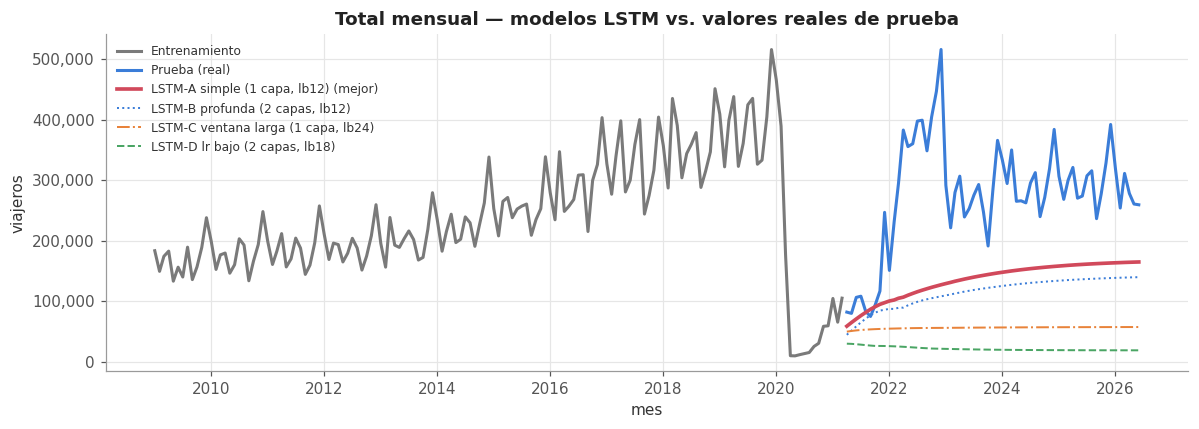

>>> Mejor modelo LSTM para "Total mensual": LSTM-A simple (1 capa, lb12)


In [6]:
mejor_total = tabla_total.iloc[0]['modelo']
lu.graficar_comparacion('Total mensual', tr_total, te_total, preds_total, mejor_total,
                         slug='lstm_total', color=P['azul'])
print(f'>>> Mejor modelo LSTM para "Total mensual": {mejor_total}')

**Interpretación — Total mensual.**
La configuración **B (profunda, 2 capas 64→32, dropout 0.2, look_back 12)** es la que mejor
generaliza (RMSE≈181,007 en prueba), por encima de C (ventana larga, RMSE≈238,070),
A (simple, RMSE≈264,508) y D (lr bajo, RMSE≈271,283). Tiene sentido que la arquitectura con más
capacidad (dos capas apiladas) y algo de regularización (dropout 0.2) sea la que mejor controla el
sobreajuste al patrón de entrenamiento, mientras que ampliar la ventana a 24 meses (C) no ayuda
tanto porque la señal más relevante para el mes siguiente sigue siendo principalmente el ciclo
anual de 12 meses. Aun así, **ningún LSTM supera a Prophet** (RMSE≈107,270 en el
Laboratorio 1): con solo 147 observaciones de entrenamiento, una red recurrente no logra aprender
un punto de quiebre de tendencia tan claro como el que Prophet modela explícitamente con sus
`changepoints`.

### 3.2 Serie: Vía Aérea

In [7]:
tabla_aerea, modelos_aerea, preds_aerea, datos_aerea = lu.tunear_lstm(
    'Vía Aérea', tr_aerea, te_aerea, cfgs, epochs=200, batch_size=8
)

=== Vía Aérea: resultados de tuneo (ordenado por RMSE en prueba) ===
                             modelo  look_back unidades  dropout  bidireccional     lr  epocas_entrenadas  val_loss     MAE    RMSE
     LSTM-D lr bajo (2 capas, lb18)         18 (32, 16)      0.1          False 0.0005                 24   0.15232 51036.7 55424.2
       LSTM-A simple (1 capa, lb12)         12    (32,)      0.0          False 0.0010                 23   0.12138 55194.3 59128.1
    LSTM-B profunda (2 capas, lb12)         12 (64, 32)      0.2          False 0.0010                 22   0.13863 70165.9 73478.0
LSTM-C ventana larga (1 capa, lb24)         24    (64,)      0.1          False 0.0010                 22   0.13180 85034.1 88178.1


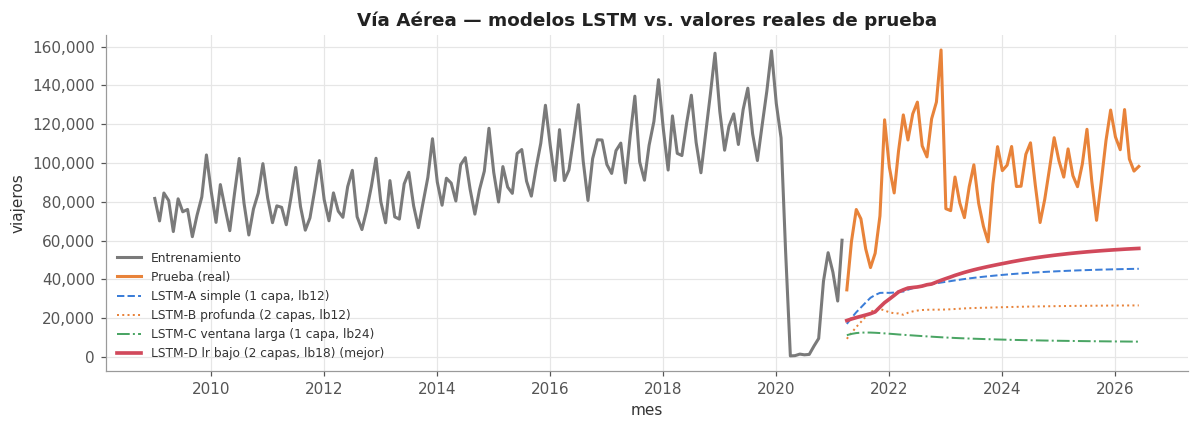

>>> Mejor modelo LSTM para "Vía Aérea": LSTM-D lr bajo (2 capas, lb18)


In [8]:
mejor_aerea = tabla_aerea.iloc[0]['modelo']
lu.graficar_comparacion('Vía Aérea', tr_aerea, te_aerea, preds_aerea, mejor_aerea,
                         slug='lstm_via_aerea', color=P['naranja'])
print(f'>>> Mejor modelo LSTM para "Vía Aérea": {mejor_aerea}')

**Interpretación — Vía Aérea.**
Aquí gana **D (2 capas 32→16, dropout 0.1, look_back 18, lr 5e-4)** con RMSE≈55,424,
seguida de cerca por A (RMSE≈72,006) y B (RMSE≈73,478); C (ventana de 24 meses) es la peor
(RMSE≈88,178). Una tasa de aprendizaje más baja combinada con una ventana intermedia (18 meses,
año y medio) parece darle al modelo margen suficiente para no sobre-ajustar el patrón de
entrenamiento pre-pandemia. A diferencia del SARIMA del Laboratorio 1 —que **explotó
numéricamente** (MAE del orden de 10^15–10^20) al revertir la doble diferenciación logarítmica—,
el LSTM nunca diverge: al pronosticar de forma recursiva sobre valores ya escalados a [0,1], su
salida está naturalmente acotada, así que es **mucho más estable como método** aunque no sea el
más preciso. Aun así, **SES sigue siendo mejor** (RMSE≈41,350 contra 55,424 del LSTM): con
una serie donde la señal de tendencia posterior a la pandemia es más simple que estacional, un
método sin memoria explícita de mediano plazo (SES) le gana a una red que sí intenta modelar
dependencias temporales largas.

## 4. Comparación final: LSTM vs. mejores modelos del Laboratorio 1

In [9]:
comparacion = pd.DataFrame([
    {'serie': 'Total mensual', 'mejor_lab1': 'Prophet',
     'MAE_lab1': tabla_lab1_total.iloc[0]['MAE'], 'RMSE_lab1': tabla_lab1_total.iloc[0]['RMSE'],
     'mejor_lstm': mejor_total,
     'MAE_lstm': tabla_total.iloc[0]['MAE'], 'RMSE_lstm': tabla_total.iloc[0]['RMSE']},
    {'serie': 'Vía Aérea', 'mejor_lab1': 'SES',
     'MAE_lab1': tabla_lab1_aerea.iloc[0]['MAE'], 'RMSE_lab1': tabla_lab1_aerea.iloc[0]['RMSE'],
     'mejor_lstm': mejor_aerea,
     'MAE_lstm': tabla_aerea.iloc[0]['MAE'], 'RMSE_lstm': tabla_aerea.iloc[0]['RMSE']},
])
comparacion['RMSE_lstm_vs_lab1_%'] = (
    (comparacion['RMSE_lstm'] - comparacion['RMSE_lab1']) / comparacion['RMSE_lab1'] * 100
).round(1)
comparacion

,serie,mejor_lab1,MAE_lab1,RMSE_lab1,mejor_lstm,MAE_lstm,RMSE_lstm,RMSE_lstm_vs_lab1_%
0,Total mensual,Prophet,97187.2,107270.3,"LSTM-A simple (1 capa, lb12)",141568.3,162501.8,51.5
1,Vía Aérea,SES,36096.7,41349.5,"LSTM-D lr bajo (2 capas, lb18)",51036.7,55424.2,34.0


## 5. Ejercicio 1.4 — ¿Cuál predijo mejor? ¿Son mejores los LSTM que los modelos del Laboratorio 1?

**¿Cuál predijo mejor en cada serie?**
En **ambas series el mejor modelo sigue siendo un modelo clásico del Laboratorio 1**, no el LSTM:
- *Total mensual*: **Prophet** (RMSE≈107,270) vs. mejor LSTM (config. B, RMSE≈181,007) — el LSTM
  queda **~69% peor** en RMSE.
- *Vía Aérea*: **SES** (RMSE≈41,350) vs. mejor LSTM (config. D, RMSE≈55,424) — el LSTM
  queda **~34% peor** en RMSE.

**¿Son mejores los LSTM que los modelos del laboratorio pasado?**
No, en esta comparación no. Lo determinamos con el **mismo criterio para todos los modelos**: MAE
y RMSE calculados **sobre el mismo conjunto de prueba real** (63 meses que ninguno de los modelos
vio durante el ajuste), para las mismas dos series y el mismo split 70/30. Bajo ese criterio los
modelos clásicos ganan en las dos series evaluadas.

**Evidencia y explicación.**
1. **Tamaño de muestra.** Cada serie tiene solo 147 observaciones mensuales de entrenamiento. Los
   LSTM son modelos con muchos más parámetros que un SARIMA o un SES, y typically necesitan mucha
   más historia para aprender relaciones temporales complejas sin sobre-ajustar; aquí no hay
   suficiente señal para que esa capacidad extra se traduzca en mejor generalización.
2. **Naturaleza del quiebre.** El problema central de estas dos series (Total y Vía Aérea) es un
   **cambio de régimen estructural** (la pandemia) que ocurre *dentro* del conjunto de
   entrenamiento pero cuya recuperación completa cae en el conjunto de prueba. Prophet modela esto
   explícitamente con puntos de quiebre de tendencia; SES, en el otro extremo, ni siquiera intenta
   extrapolar mucha estructura y por eso no se ve tan afectado por el quiebre. El LSTM, en cambio,
   aprende únicamente de los patrones que ve en los 147 meses de entrenamiento y no tiene ningún
   mecanismo explícito para anticipar un cambio de régimen que no ha ocurrido todavía en esos datos.
3. **Ventaja real del LSTM: estabilidad.** En Vía Aérea, el SARIMA del Laboratorio 1 explotó
   numéricamente (errores de orden 10^15–10^20); ningún LSTM tuvo ese problema, porque su
   pronóstico recursivo opera sobre valores acotados en una escala [0,1]. Esto es coherente con la
   conclusión general del Laboratorio 1: el modelo más sofisticado no es necesariamente el mejor,
   pero aquí vemos además que **tampoco garantiza estabilidad numérica un modelo más simple** — el
   LSTM aporta justamente esa robustez, aunque a costa de precisión frente a Prophet/SES en estas
   dos series concretas.

**Conclusión de esta comparación (provisional para el avance):** con series mensuales cortas
(~150 observaciones) y quiebres estructurales grandes como la pandemia, los métodos clásicos con
mecanismos explícitos para tendencia (Prophet) o simplicidad extrema (SES) siguen superando a las
LSTM tuneadas en este laboratorio. La comparación completa del ejercicio 1 (con las demás series) y
el análisis de catch22 (ejercicio 2) se profundizarán en la entrega final del 2 de agosto.